In [19]:
import xarray as xr
from pathlib import Path

import numpy as np
import pandas as pd

#xr.set_options(display_style="text") # make it look better when posted online. Comment to get nicer representation of xarrays
import os

# dates for CMIP data
sdate,edate = 2000, 2009

# model for CMIP data
cmip_model = 'r2i1p1f1'
if cmip_model != 'r1i1p1f1':
    print('WARNING: CMIP model for latent heat and soil moisture different to precip (r1i1p1f1)!')

## ICON SRM data

In [7]:
## ICON SRM
datapath = '/g/data/qx55/germany_node/d3hp003.zarr'
file = 'P1D'
zoom = 'z6'

# define the fname
fpath = f'{datapath}/{file}_mean_{zoom}_atm.zarr'

# open the zarr file
icon_ds = xr.open_zarr(fpath)

'''
karl-hermann.wieners 5:00 PM
Hi Mat, sorry for the trouble. I'll see whether this can be fixed. The values should be
soil_level = [0.0325, 0.192, 0.7755, 2.683, 6.984]
'''
# Assign new soil_level values per karl's mattermost message
icon_ds = icon_ds.assign_coords(soil_level=np.array([0.0325, 0.192, 0.7755, 2.683, 6.984]))

## CMIP data

In [3]:
## CMIP
import re

def get_cmip_icon(folder_path,syear,eyear):

    # List all .nc files in the folder
    all_files = [f for f in os.listdir(folder_path) if f.endswith(".nc")]

    # Filter files based on year in the name
    selected_files = []
    for f in all_files:
        match = re.search(r'(\d{8})-(\d{8})', f)
        if match:
            start_year = int(match.group(1)[:4])
            end_year = int(match.group(2)[:4])
            if start_year >= syear and end_year <= eyear:
                selected_files.append(os.path.join(folder_path, f))

    # Open multiple files using xarray
    return xr.open_mfdataset(selected_files)

In [21]:
### CMIP precip (pr) ###
# folder_path = "/g/data/fy29/mjl561/cmip/"
folder_path = '/scratch/nf33/cmip'

cmip_pr =get_cmip_icon(folder_path,sdate,edate)['pr']

In [47]:
### CMIP soil moisture (mrsol) ###
folder_path = f"/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/ICON-ESM-LR/historical/{cmip_model}/Eday/mrsol/gn/v20210215"

cmip_sm = get_cmip_icon(folder_path,sdate,edate)['mrsol']

In [48]:
### CMIP soil moisture (mrsol) ###
folder_path = f"/g/data/oi10/replicas/CMIP6/CMIP/MPI-M/ICON-ESM-LR/historical/{cmip_model}/day/hfls/gn/v20210215"

cmip_hfls = get_cmip_icon(folder_path,sdate,edate)['hfls']

## processing

In [101]:
# select land_area_fraction for mask
icon_land = icon_ds['sftlf']

# convert precipitation to daily mean for mask
icon_pr_mean = icon_ds['pr'].mean('time')*86400

# convert precipitation to daily mean for mask
cmip_pr_mean = cmip_pr.mean('time')*86400

# create mask (use soil mask as no land frac for cmip)
cmip_mask = (cmip_pr_mean>=.1)&(cmip_sm.isel(depth=0,time=0).notnull()).compute()
icon_mask = (icon_pr_mean>=.1)&(icon_land >0.9).compute()

In [140]:
print('WARNING: temporarily testing with soil depth=2')
depth=2

In [141]:
icon_smi = xr.where( icon_mask, icon_ds['mrso'].isel(soil_level=depth), np.NaN)
icon_y1  = xr.where( icon_mask, icon_ds['hflsd'], np.NaN)
# icon_y2  = xr.where( icon_mask, dataICON['hfss'], np.NaN)

icon_corr_lh_pr      = xr.where(icon_mask, xr.corr(icon_ds['pr'], icon_y1, dim='time'), np.NaN) #.values
# icon_corr_sh_pr      = xr.where((cmip_pr>=.1)&(icon_pr>=.1)&( land_frac['fract_lake'] < 0.1), 
#                                 xr.corr(dataICON['pr'], icon_y2, dim='time'), np.NaN) #.values
icon_corr_pr_smi  = xr.where(icon_mask, xr.corr(icon_ds['mrso'], icon_ds['pr'], dim='time'), np.NaN) #.values

In [105]:
cmip_smi = xr.where( cmip_mask, cmip_sm.isel(depth=depth), np.NaN)
cmip_y1  = xr.where( cmip_mask, cmip_hfls, np.NaN)
# cmip_y2  = xr.where( (icon_pr>=.1)&(cmip_pr>=.1)&( land_frac['fract_lake']<0.1), dataCMIP['hfss'], np.NaN)

cmip_corr_lh_pr      = xr.where(cmip_mask, xr.corr(cmip_pr*86400., cmip_y1, dim='time'), np.NaN).values
# cmip_corr_sh_pr      = xr.where((icon_pr>=.1)&(cmip_pr>=.1)&( land_frac['fract_lake'] < 0.1), 
#                                 xr.corr(dataCMIP['pr']*86400., cmip_y2, dim='time'), np.NaN).values

In [ ]:
cmip_corr_pr_smi  = xr.where(cmip_mask, xr.corr(cmip_sm.isel(depth=depth), cmip_pr*86400, dim='time'), np.NaN).values


In [263]:
icon_et_masked = xr.where(icon_mask, (-icon_ds['hflsd'] * 86400) / (2.501e6), np.NaN)
icon_pr_masked = xr.where(icon_mask, icon_ds['pr'] * 86400, np.NaN)

In [264]:
cmip_et_masked = xr.where(cmip_mask, (cmip_hfls * 86400) / (2.501e6), np.NaN)
cmip_pr_masked = xr.where(cmip_mask, cmip_pr * 86400, np.NaN)

In [270]:
import numpy as np
import matplotlib.pyplot as plt

def process_model_data(et_data, pr_data, model_name):
    """Process model data for binned plotting"""
    # Flatten the data and remove NaN values
    x_flat = et_data.values.flatten()
    y_flat = pr_data.values.flatten()
    
    # Remove NaN values (from masking)
    valid_mask = ~(np.isnan(x_flat) | np.isnan(y_flat))
    x = x_flat[valid_mask]
    y = y_flat[valid_mask]
    
    print(f"{model_name} - Total data points after removing NaN: {len(x)}")
    print(f"{model_name} - ET range: {x.min():.3f} to {x.max():.3f} mm/day")
    print(f"{model_name} - PR range: {y.min():.3f} to {y.max():.3f} mm/day")
    
    return x, y

# Process both models
threshold = 0.003
nbins = 100

# Process ICON data
x_icon, y_icon = process_model_data(icon_et_masked, icon_pr_masked, "ICON")

# Process CMIP data  
x_cmip, y_cmip = process_model_data(cmip_et_masked, cmip_pr_masked, "CMIP")

# Determine common bin range for both models
x_min = min(x_icon.min(), x_cmip.min())
x_max = max(x_icon.max(), x_cmip.max())
bins = np.linspace(x_min, x_max, nbins+1)
x_centers = (bins[:-1] + bins[1:]) / 2.0

def calculate_binned_means(x, y, bins, threshold):
    """Calculate binned means with threshold filtering"""
    inds = np.digitize(x, bins)
    total_points = len(x)
    min_points_per_bin = int(threshold * total_points)
    
    y_means = []
    bin_counts = []
    for i in range(1, len(bins)):
        bin_mask = (inds == i)
        bin_count = np.sum(bin_mask)
        bin_counts.append(bin_count)
        
        if bin_count >= min_points_per_bin:
            y_means.append(y[bin_mask].mean())
        else:
            y_means.append(np.nan)
    
    return np.array(y_means), np.array(bin_counts), min_points_per_bin

# Calculate binned means for both models
y_means_icon, bin_counts_icon, min_points_icon = calculate_binned_means(x_icon, y_icon, bins, threshold)
y_means_cmip, bin_counts_cmip, min_points_cmip = calculate_binned_means(x_cmip, y_cmip, bins, threshold)

print(f"\nICON - Minimum points per bin ({threshold:.1%} threshold): {min_points_icon}")
print(f"ICON - Bins with sufficient data: {np.sum(~np.isnan(y_means_icon))}/{len(y_means_icon)}")
print(f"CMIP - Minimum points per bin ({threshold:.1%} threshold): {min_points_cmip}")
print(f"CMIP - Bins with sufficient data: {np.sum(~np.isnan(y_means_cmip))}/{len(y_means_cmip)}")

# Plot both models
valid_icon = ~np.isnan(y_means_icon)
valid_cmip = ~np.isnan(y_means_cmip)


ICON - Total data points after removing NaN: 5190100
ICON - ET range: -8.439 to 15.689 mm/day
ICON - PR range: 0.000 to 387.717 mm/day
CMIP - Total data points after removing NaN: 25392003
CMIP - ET range: -9.693 to 37.881 mm/day
CMIP - PR range: 0.000 to 209.368 mm/day

ICON - Minimum points per bin (0.3% threshold): 15570
ICON - Bins with sufficient data: 14/100
CMIP - Minimum points per bin (0.3% threshold): 76176
CMIP - Bins with sufficient data: 16/100


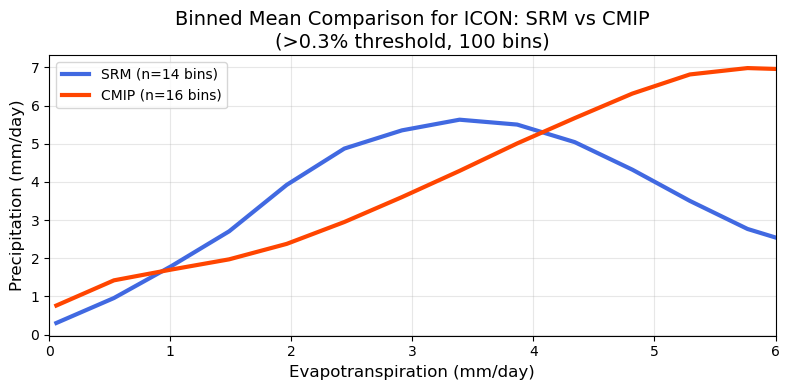


Summary:
ICON: 14/100 valid bins
CMIP: 16/100 valid bins
Common ET range: -9.693 to 37.881 mm/day


In [273]:
plt.close('all')
plt.figure(figsize=(8, 4))
# Plot ICON model in blue
plt.plot(x_centers[valid_icon], y_means_icon[valid_icon],
         c='royalblue', linewidth=3, 
         label=f'SRM (n={np.sum(valid_icon)} bins)')

# Plot CMIP model in red
plt.plot(x_centers[valid_cmip], y_means_cmip[valid_cmip],
         c='orangered', linewidth=3, 
         label=f'CMIP (n={np.sum(valid_cmip)} bins)')

plt.xlim(0,6)

plt.xlabel('Evapotranspiration (mm/day)', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.title(f'Binned Mean Comparison for ICON: SRM vs CMIP\n(>{threshold:.1%} threshold, {nbins} bins)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"ICON: {np.sum(valid_icon)}/{len(y_means_icon)} valid bins")
print(f"CMIP: {np.sum(valid_cmip)}/{len(y_means_cmip)} valid bins")
print(f"Common ET range: {x_min:.3f} to {x_max:.3f} mm/day")